# Guardrails Contribution (Point 2)

Notebook khusus untuk plot dan tabel kontribusi guardrails/admission stabilization.


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_SEED = 7
BLOCK_LEN = 5
N_BOOT = 2000

# Resolve project root (works from repo root or /notebooks)
PROJECT_ROOT = Path.cwd().resolve()
for _ in range(4):
    if (PROJECT_ROOT / 'results').exists() and (PROJECT_ROOT / 'src').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASETS = {
    'wikipedia_september_2007': PROJECT_ROOT / 'results/wikipedia_september_2007',
    'wiki2018': PROJECT_ROOT / 'results/wiki2018',
}

FEATURE_SET = 'A2'
RUN_PREFIX = '001'

VARIANTS = {
    'no_guard': 'guard_no_guard_NB',
    'precision_only': 'guard_precision_only',
    'quality_only': 'guard_quality_only',
    'full_guard': 'guard_full_NB',
    'rate_matched': 'guard_rate_matched',
}

VARIANT_LABELS = {
    'no_guard': 'No-Guard',
    'precision_only': 'Precision-only',
    'quality_only': 'Quality-only',
    'full_guard': 'Full guard',
    'rate_matched': 'Rate-matched',
}

FIG_DIR = PROJECT_ROOT / 'results/figures'
TAB_DIR = PROJECT_ROOT / 'results/tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})


In [2]:
def list_sizes(root: Path, suffix: str):
    sizes = set()
    pattern = f"{RUN_PREFIX}_summary_ilnse_{FEATURE_SET}_{suffix}_*.json"
    for p in root.glob(pattern):
        try:
            size = int(p.stem.split('_')[-1])
            sizes.add(size)
        except Exception:
            pass
    return sorted(sizes)


def load_summary(root: Path, suffix: str, size: int):
    path = root / f"{RUN_PREFIX}_summary_ilnse_{FEATURE_SET}_{suffix}_{size}.json"
    with path.open() as f:
        return json.load(f)


def load_slot_rows(root: Path, suffix: str, size: int):
    path = root / f"{RUN_PREFIX}_ilnse_{FEATURE_SET}_{suffix}_{size}.jsonl"
    rows = []
    with path.open() as f:
        for line in f:
            row = json.loads(line)
            if row.get('phase') != 'cache':
                continue
            rows.append(row)
    return rows


def block_bootstrap_mean_ci(values, block_len=BLOCK_LEN, n_boot=N_BOOT, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return float('nan'), float('nan'), float('nan')
    mean = float(np.mean(v))
    n = len(v)
    max_start = max(0, n - block_len)
    starts = np.arange(max_start + 1)
    n_blocks = int(np.ceil(n / block_len))
    boots = []
    for _ in range(n_boot):
        idx = rng.choice(starts, size=n_blocks, replace=True)
        blocks = []
        for s in idx:
            blocks.append(np.arange(s, min(s + block_len, n)))
        samp = np.concatenate(blocks)[:n]
        boots.append(float(np.mean(v[samp])))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return mean, float(lo), float(hi)


def build_metrics(root: Path):
    rows = []
    for vkey, suffix in VARIANTS.items():
        sizes = list_sizes(root, suffix)
        for size in sizes:
            s = load_summary(root, suffix, size)
            hit_ratio = s.get('hit_ratio')
            cache_requests = s.get('cache_requests')
            admit_applied_total = s.get('admit_applied_total')
            miss_candidates_total = s.get('miss_candidates_total')
            pollution_rate_total = s.get('pollution_rate_total')
            hit_yield_total = s.get('hit_yield_total')
            miss_rate_avg = s.get('miss_rate_avg')

            admission_rate_candidates = None
            if miss_candidates_total:
                admission_rate_candidates = admit_applied_total / miss_candidates_total

            admission_rate_requests = None
            if cache_requests:
                admission_rate_requests = admit_applied_total / cache_requests

            rows.append({
                'dataset': root.name,
                'variant': vkey,
                'variant_label': VARIANT_LABELS.get(vkey, vkey),
                'cache_size': size,
                'hit_ratio': hit_ratio,
                'miss_rate_avg': miss_rate_avg,
                'admit_applied_total': admit_applied_total,
                'cache_requests': cache_requests,
                'miss_candidates_total': miss_candidates_total,
                'admission_rate_candidates': admission_rate_candidates,
                'admission_rate_requests': admission_rate_requests,
                'pollution_rate_total': pollution_rate_total,
                'hit_yield_total': hit_yield_total,
            })
    return pd.DataFrame(rows)


def build_hr_ci(root: Path, suffix: str, size: int):
    rows = load_slot_rows(root, suffix, size)
    hrs = [r.get('slot_hit_ratio') for r in rows if r.get('slot_hit_ratio') is not None]
    mean, lo, hi = block_bootstrap_mean_ci(hrs)
    return mean, lo, hi


def smooth_series(x, window=5):
    if window <= 1:
        return x
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    for i in range(len(x)):
        j0 = max(0, i - window + 1)
        out[i] = np.nanmean(x[j0:i+1])
    return out


In [3]:
# Build dataset metrics
metrics = []
for name, root in DATASETS.items():
    df = build_metrics(root)
    metrics.append(df)

metrics = pd.concat(metrics, ignore_index=True)
metrics.head()


,dataset,variant,variant_label,cache_size,hit_ratio,miss_rate_avg,admit_applied_total,cache_requests,miss_candidates_total,admission_rate_candidates,admission_rate_requests,pollution_rate_total,hit_yield_total
0,wikipedia_september_2007,no_guard,No-Guard,12221,0.631308,0.368692,39098,8000000,2767604,0.014127,0.004887,0.464474,1.904164
1,wikipedia_september_2007,no_guard,No-Guard,15277,0.639001,0.360999,48739,8000000,2719663,0.017921,0.006092,0.530643,1.548370
2,wikipedia_september_2007,no_guard,No-Guard,30554,0.666640,0.333360,171351,8000000,2533715,0.067628,0.021419,0.690950,0.547794
3,wikipedia_september_2007,no_guard,No-Guard,45831,0.683920,0.316080,335487,8000000,2407028,0.139378,0.041936,0.747537,0.335286
4,wikipedia_september_2007,no_guard,No-Guard,61109,0.695575,0.304425,445071,8000000,2320814,0.191774,0.055634,0.792305,0.260673


In [4]:
# Compute HR mean + CI (slot-level) for ablation variants only
ci_rows = []
for name, root in DATASETS.items():
    for vkey in ['no_guard', 'precision_only', 'quality_only', 'full_guard']:
        suffix = VARIANTS[vkey]
        for size in list_sizes(root, suffix):
            mean, lo, hi = build_hr_ci(root, suffix, size)
            ci_rows.append({
                'dataset': root.name,
                'variant': vkey,
                'variant_label': VARIANT_LABELS[vkey],
                'cache_size': size,
                'hit_ratio': mean,
                'ci_lo': lo,
                'ci_hi': hi,
            })

hr_ci = pd.DataFrame(ci_rows)
hr_ci.head()


,dataset,variant,variant_label,cache_size,hit_ratio,ci_lo,ci_hi
0,wikipedia_september_2007,no_guard,No-Guard,12221,0.631308,0.623228,0.647771
1,wikipedia_september_2007,no_guard,No-Guard,15277,0.639001,0.631280,0.655206
2,wikipedia_september_2007,no_guard,No-Guard,30554,0.666640,0.660956,0.680411
3,wikipedia_september_2007,no_guard,No-Guard,45831,0.683920,0.679140,0.697305
4,wikipedia_september_2007,no_guard,No-Guard,61109,0.695575,0.690238,0.709479


In [5]:
def plot_metric_vs_size(df, dataset, metric, ylabel, title, out_prefix, variants=None, err_df=None):
    data = df[df['dataset'] == dataset].copy()
    if variants:
        data = data[data['variant'].isin(variants)]
    fig, ax = plt.subplots(figsize=(6.4, 3.6))

    for vkey, g in data.groupby('variant'):
        label = VARIANT_LABELS.get(vkey, vkey)
        g = g.sort_values('cache_size')
        x = g['cache_size'].values
        y = g[metric].values
        if err_df is not None and metric == 'hit_ratio':
            e = err_df[(err_df['dataset'] == dataset) & (err_df['variant'] == vkey)].sort_values('cache_size')
            if len(e) == len(g):
                yerr = np.vstack([y - e['ci_lo'].values, e['ci_hi'].values - y])
                ax.errorbar(x, y, yerr=yerr, marker='o', capsize=3, label=label)
            else:
                ax.plot(x, y, marker='o', label=label)
        else:
            ax.plot(x, y, marker='o', label=label)

    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'{out_prefix}.png')
    fig.savefig(FIG_DIR / f'{out_prefix}.pdf')
    plt.show()
    plt.close(fig)


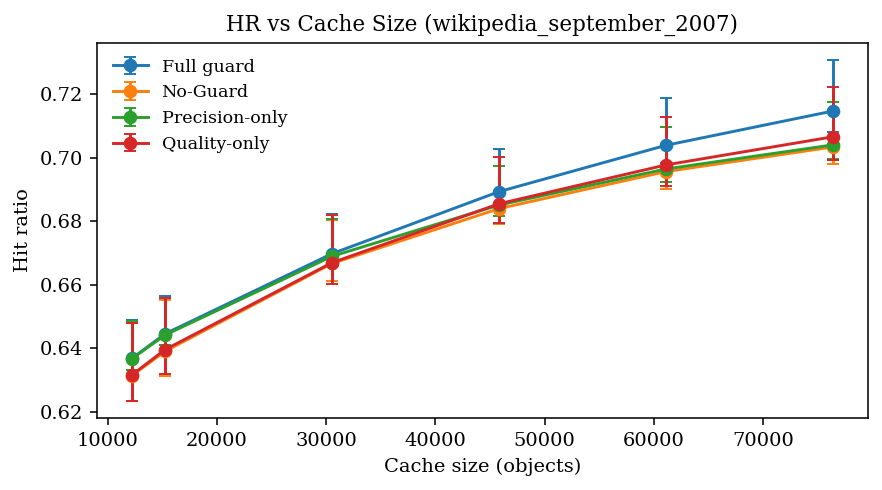

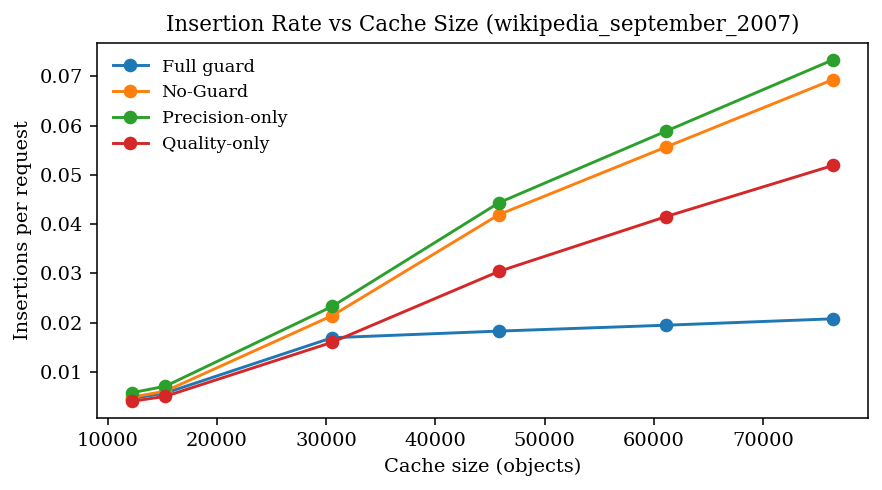

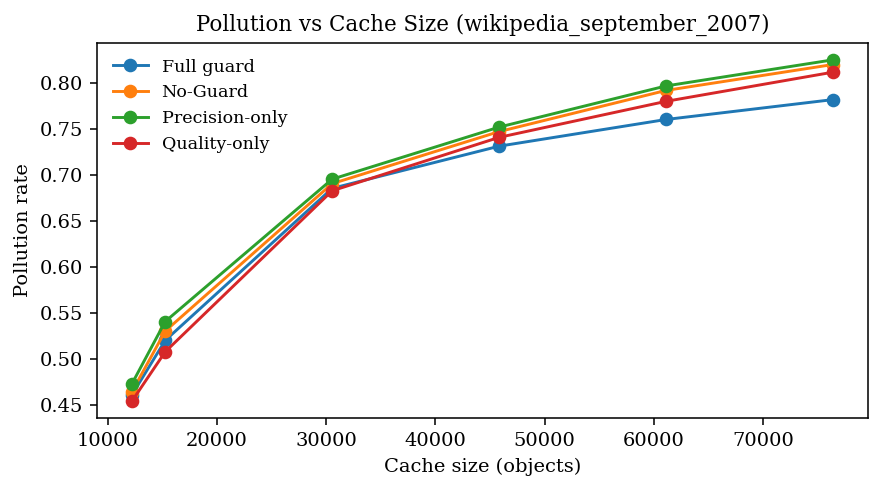

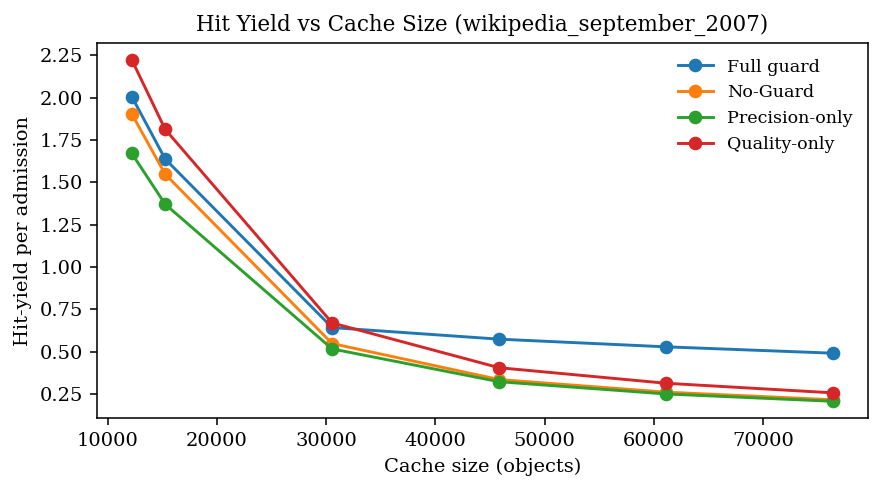

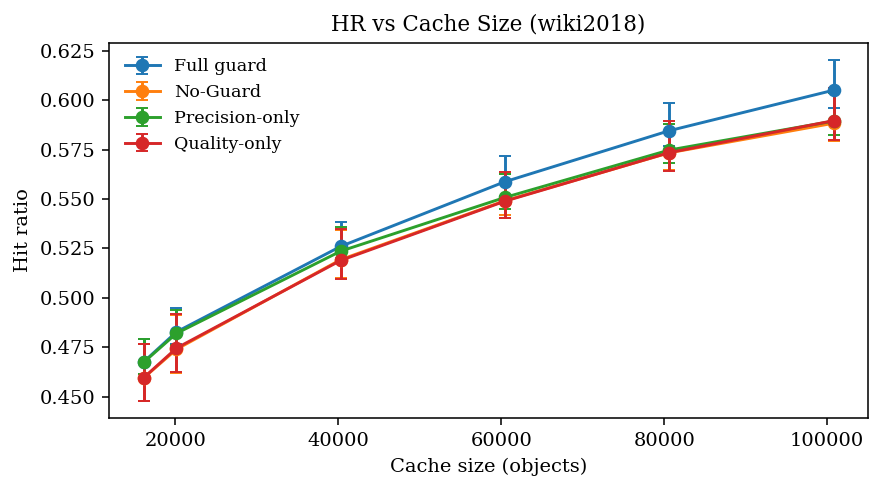

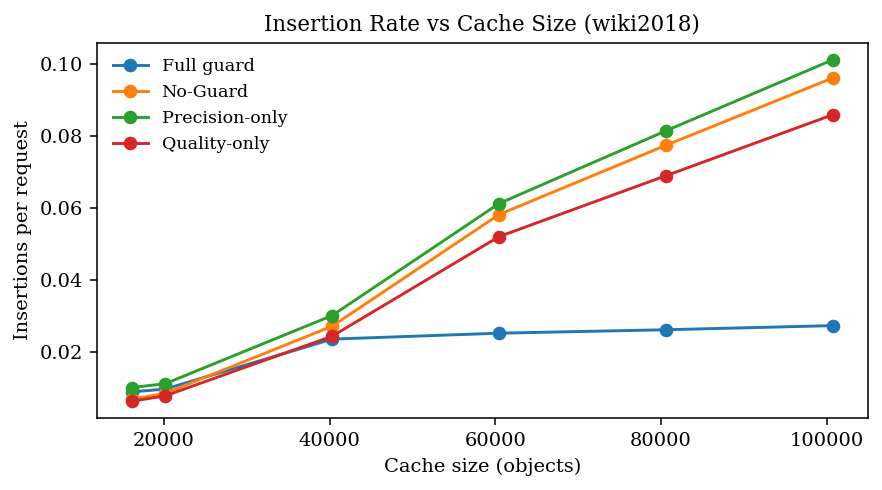

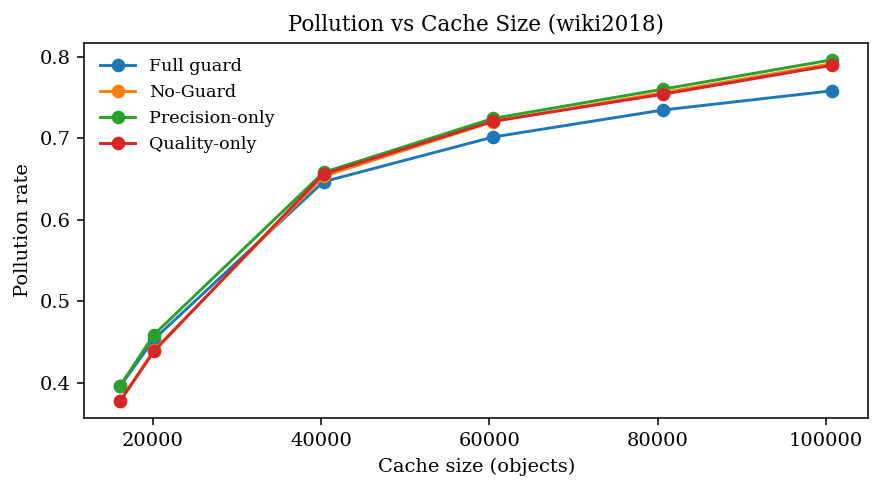

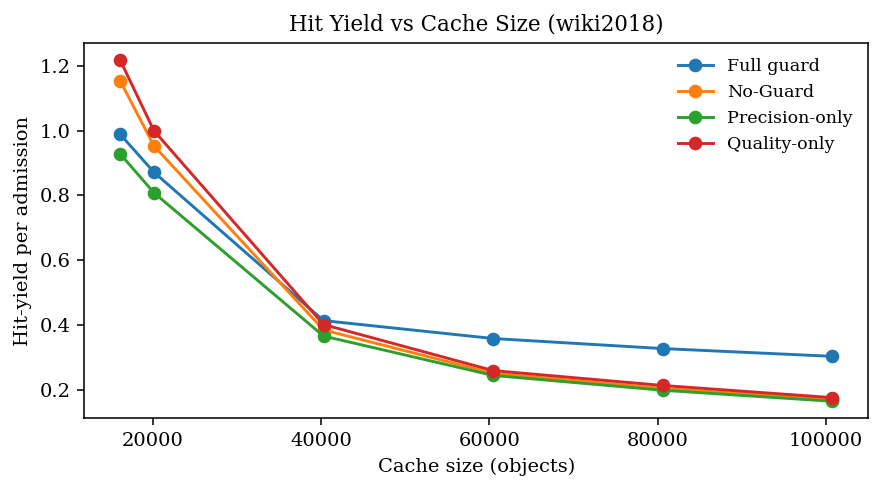

In [6]:
# Outcome plots for ablation variants
for dataset in DATASETS.keys():
    plot_metric_vs_size(
        metrics, dataset, 'hit_ratio', 'Hit ratio',
        f'HR vs Cache Size ({dataset})',
        f'guardrails_hr_{dataset}',
        variants=['no_guard', 'precision_only', 'quality_only', 'full_guard'],
        err_df=hr_ci,
    )

    plot_metric_vs_size(
        metrics, dataset, 'admission_rate_requests', 'Insertions per request',
        f'Insertion Rate vs Cache Size ({dataset})',
        f'guardrails_insertions_{dataset}',
        variants=['no_guard', 'precision_only', 'quality_only', 'full_guard'],
    )

    plot_metric_vs_size(
        metrics, dataset, 'pollution_rate_total', 'Pollution rate',
        f'Pollution vs Cache Size ({dataset})',
        f'guardrails_pollution_{dataset}',
        variants=['no_guard', 'precision_only', 'quality_only', 'full_guard'],
    )

    plot_metric_vs_size(
        metrics, dataset, 'hit_yield_total', 'Hit-yield per admission',
        f'Hit Yield vs Cache Size ({dataset})',
        f'guardrails_hit_yield_{dataset}',
        variants=['no_guard', 'precision_only', 'quality_only', 'full_guard'],
    )


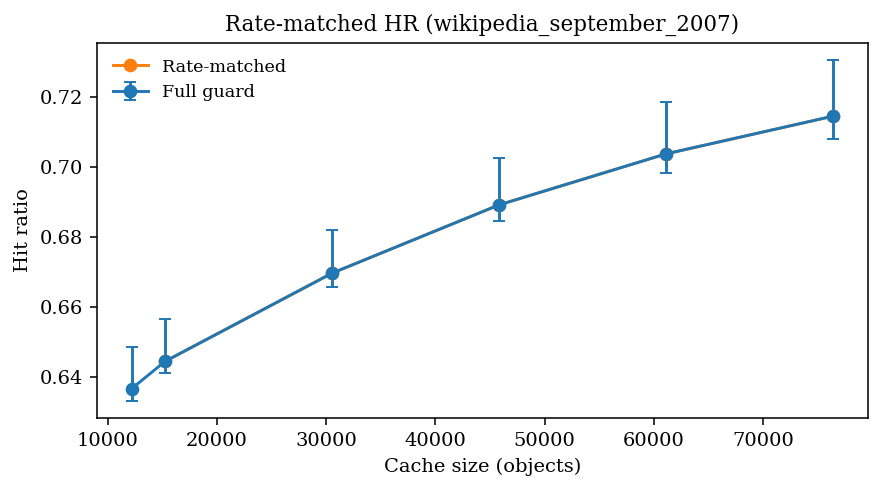

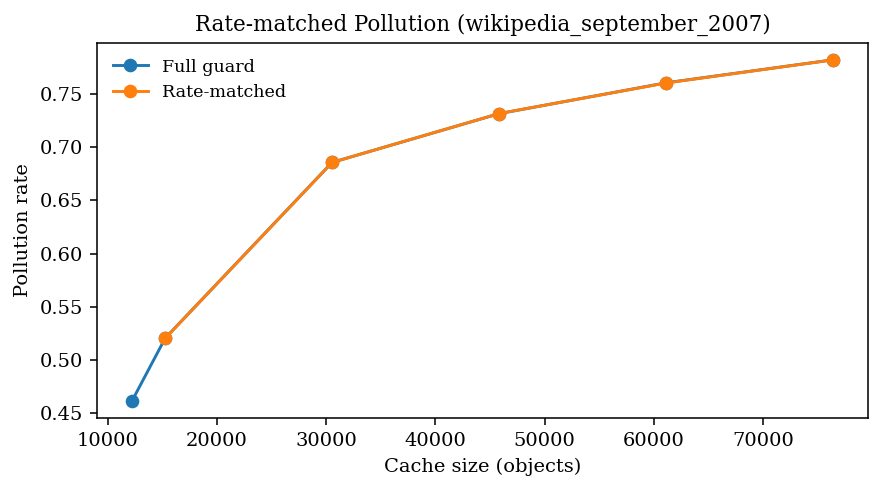

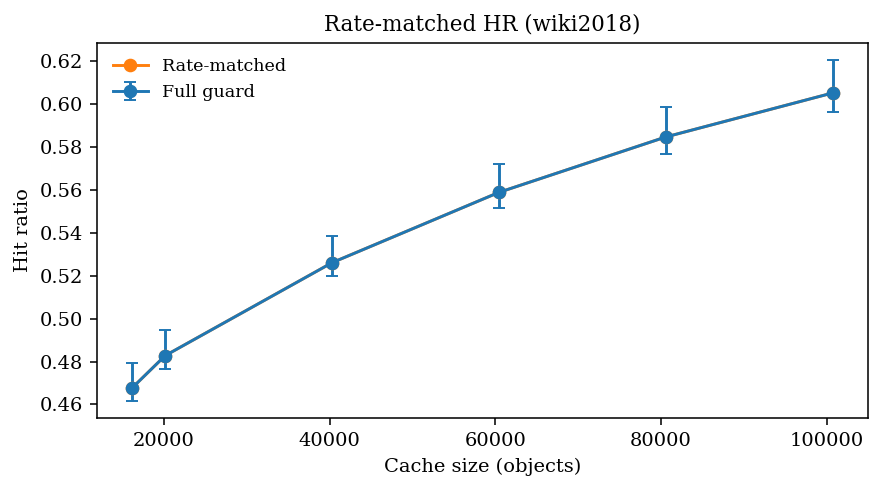

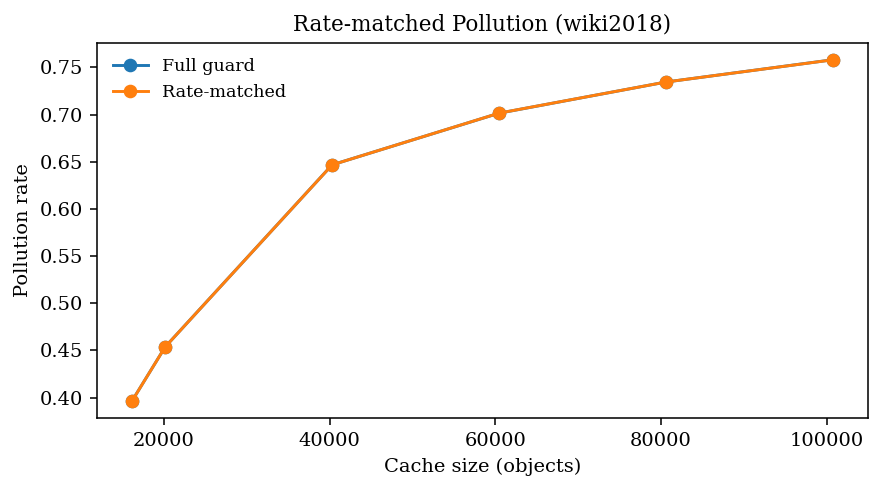

In [7]:
# Rate-matched control: full guard vs rate-matched
for dataset in DATASETS.keys():
    plot_metric_vs_size(
        metrics, dataset, 'hit_ratio', 'Hit ratio',
        f'Rate-matched HR ({dataset})',
        f'guardrails_rate_matched_hr_{dataset}',
        variants=['full_guard', 'rate_matched'],
        err_df=hr_ci,
    )

    plot_metric_vs_size(
        metrics, dataset, 'pollution_rate_total', 'Pollution rate',
        f'Rate-matched Pollution ({dataset})',
        f'guardrails_rate_matched_pollution_{dataset}',
        variants=['full_guard', 'rate_matched'],
    )


/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_13060/1986989922.py:108: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[j0:i+1])


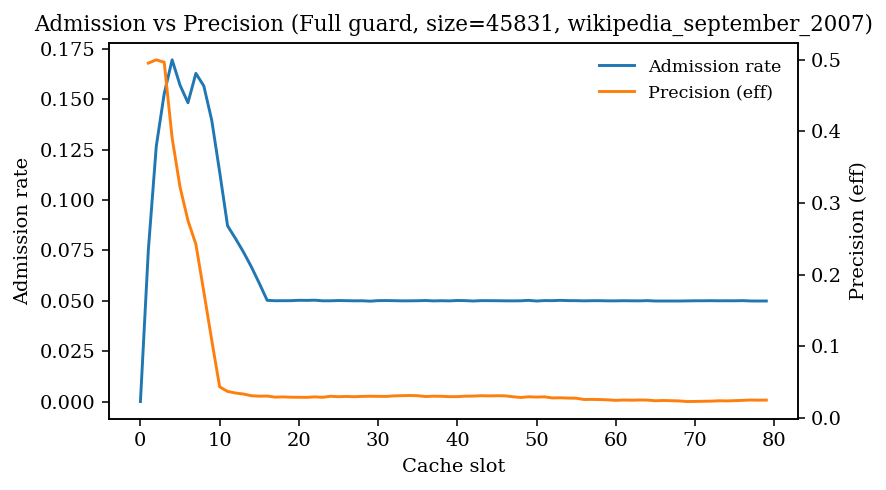

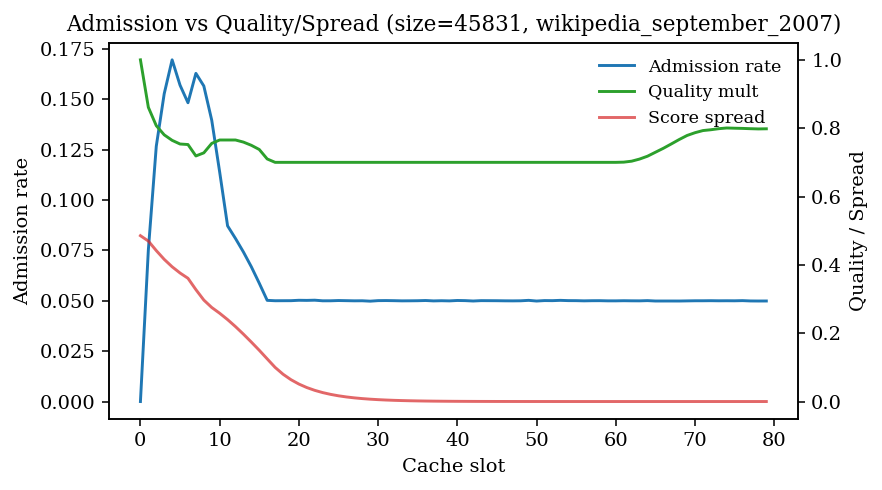

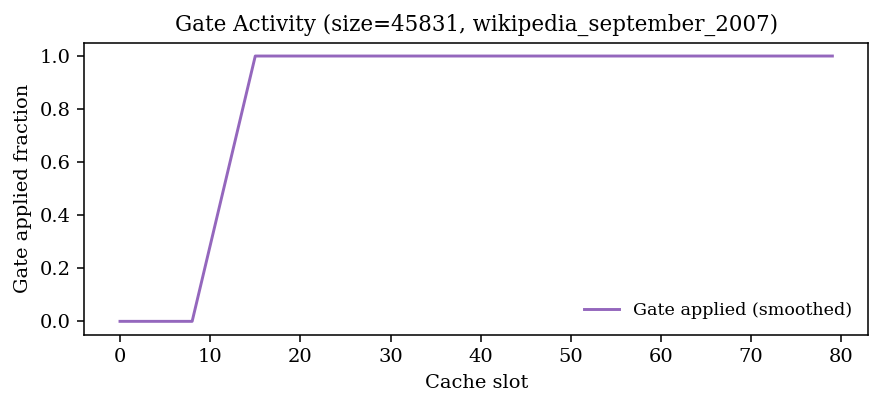

/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_13060/1986989922.py:108: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[j0:i+1])


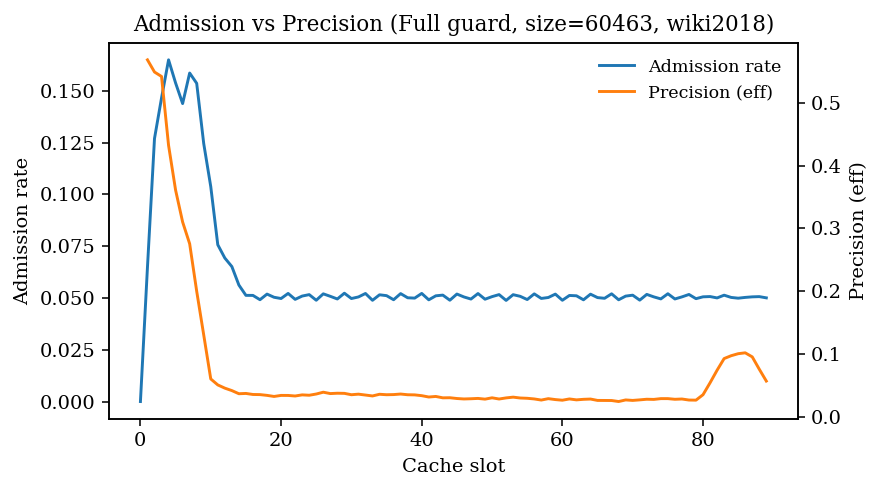

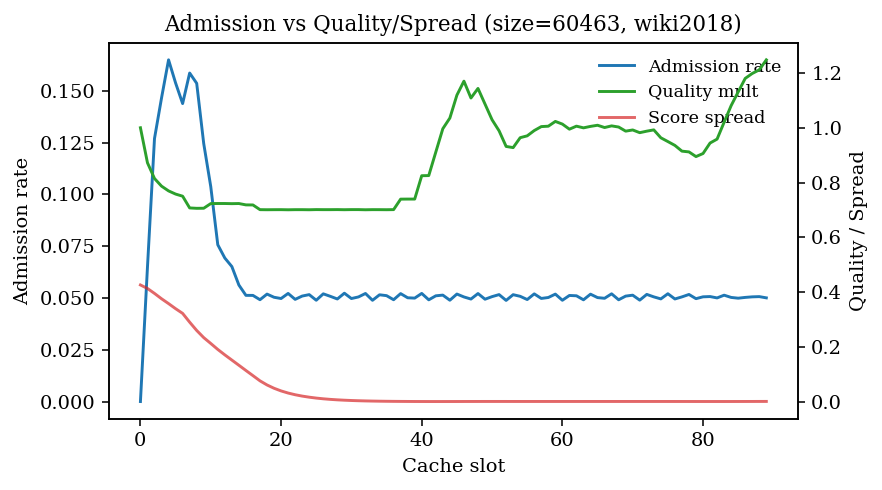

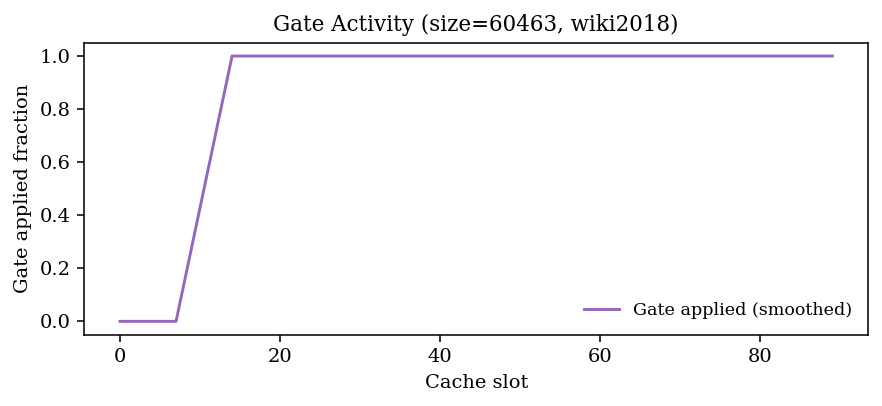

In [8]:
# Mechanism plots (time series) for full guard
MECH_VARIANT = 'full_guard'
MECH_WINDOW = 7

for dataset, root in DATASETS.items():
    sizes = list_sizes(root, VARIANTS[MECH_VARIANT])
    if not sizes:
        continue
    size = sizes[len(sizes)//2]
    rows = load_slot_rows(root, VARIANTS[MECH_VARIANT], size)

    miss_candidates = np.array([r.get('miss_candidates') or 0 for r in rows], dtype=float)
    admit_applied = np.array([r.get('admit_applied') or 0 for r in rows], dtype=float)
    admission_rate = np.divide(admit_applied, np.maximum(1.0, miss_candidates))

    precision_eff = np.array([
        r.get('admission_precision_eff') if r.get('admission_precision_eff') is not None else np.nan
        for r in rows
    ], dtype=float)
    quality_mult = np.array([r.get('quality_mult', np.nan) for r in rows], dtype=float)
    spread = np.array([
        r.get('score_spread_ema') if r.get('score_spread_ema') is not None else r.get('score_spread', np.nan)
        for r in rows
    ], dtype=float)
    gate_applied = np.array([1.0 if r.get('score_gate_applied') else 0.0 for r in rows], dtype=float)

    admission_rate_s = smooth_series(admission_rate, MECH_WINDOW)
    precision_eff_s = smooth_series(precision_eff, MECH_WINDOW)
    quality_mult_s = smooth_series(quality_mult, MECH_WINDOW)
    spread_s = smooth_series(spread, MECH_WINDOW)
    gate_applied_s = smooth_series(gate_applied, MECH_WINDOW)

    # Plot 1: admission rate vs precision_eff
    fig, ax1 = plt.subplots(figsize=(6.4, 3.6))
    ax1.plot(admission_rate_s, color='tab:blue', label='Admission rate')
    ax1.set_ylabel('Admission rate')
    ax1.set_xlabel('Cache slot')

    ax2 = ax1.twinx()
    ax2.plot(precision_eff_s, color='tab:orange', label='Precision (eff)')
    ax2.set_ylabel('Precision (eff)')

    ax1.set_title(f'Admission vs Precision (Full guard, size={size}, {dataset})')
    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'guardrails_mech_precision_{dataset}.png')
    fig.savefig(FIG_DIR / f'guardrails_mech_precision_{dataset}.pdf')
    plt.show()
    plt.close(fig)

    # Plot 2: admission rate vs quality/score spread
    fig, ax1 = plt.subplots(figsize=(6.4, 3.6))
    ax1.plot(admission_rate_s, color='tab:blue', label='Admission rate')
    ax1.set_ylabel('Admission rate')
    ax1.set_xlabel('Cache slot')

    ax2 = ax1.twinx()
    ax2.plot(quality_mult_s, color='tab:green', label='Quality mult')
    ax2.plot(spread_s, color='tab:red', alpha=0.7, label='Score spread')
    ax2.set_ylabel('Quality / Spread')

    ax1.set_title(f'Admission vs Quality/Spread (size={size}, {dataset})')
    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'guardrails_mech_quality_{dataset}.png')
    fig.savefig(FIG_DIR / f'guardrails_mech_quality_{dataset}.pdf')
    plt.show()
    plt.close(fig)

    # Plot 3: gate applied fraction
    fig, ax = plt.subplots(figsize=(6.4, 3.0))
    ax.plot(gate_applied_s, color='tab:purple', label='Gate applied (smoothed)')
    ax.set_xlabel('Cache slot')
    ax.set_ylabel('Gate applied fraction')
    ax.set_title(f'Gate Activity (size={size}, {dataset})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'guardrails_mech_gate_{dataset}.png')
    fig.savefig(FIG_DIR / f'guardrails_mech_gate_{dataset}.pdf')
    plt.show()
    plt.close(fig)


In [9]:
# Save tables for paper
metrics_out = metrics.copy()
metrics_out.to_csv(TAB_DIR / 'guardrails_metrics_table.csv', index=False)
metrics_out.to_latex(TAB_DIR / 'guardrails_metrics_table.tex', index=False, float_format='%.6f')

hr_ci_out = hr_ci.copy()
hr_ci_out.to_csv(TAB_DIR / 'guardrails_hr_ci_table.csv', index=False)
hr_ci_out.to_latex(TAB_DIR / 'guardrails_hr_ci_table.tex', index=False, float_format='%.6f')

metrics_out.head()


/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_13060/2609149797.py:4: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  metrics_out.to_latex(TAB_DIR / 'guardrails_metrics_table.tex', index=False, float_format='%.6f')
/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_13060/2609149797.py:8: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  hr_ci_out.to_latex(TAB_DIR / 'guardrails_hr_ci_table.tex', index=False, float_format='%.6f')


,dataset,variant,variant_label,cache_size,hit_ratio,miss_rate_avg,admit_applied_total,cache_requests,miss_candidates_total,admission_rate_candidates,admission_rate_requests,pollution_rate_total,hit_yield_total
0,wikipedia_september_2007,no_guard,No-Guard,12221,0.631308,0.368692,39098,8000000,2767604,0.014127,0.004887,0.464474,1.904164
1,wikipedia_september_2007,no_guard,No-Guard,15277,0.639001,0.360999,48739,8000000,2719663,0.017921,0.006092,0.530643,1.548370
2,wikipedia_september_2007,no_guard,No-Guard,30554,0.666640,0.333360,171351,8000000,2533715,0.067628,0.021419,0.690950,0.547794
3,wikipedia_september_2007,no_guard,No-Guard,45831,0.683920,0.316080,335487,8000000,2407028,0.139378,0.041936,0.747537,0.335286
4,wikipedia_september_2007,no_guard,No-Guard,61109,0.695575,0.304425,445071,8000000,2320814,0.191774,0.055634,0.792305,0.260673


## Additional plots for contribution point 2

Delta plots (Full guard vs ablations), Pareto curves, and mechanism time series.


In [10]:
def block_bootstrap_mean_diff(a, b, block_len=BLOCK_LEN, n_boot=N_BOOT, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    n = min(len(a), len(b))
    if n == 0:
        return float('nan'), float('nan'), float('nan')
    a = a[:n]
    b = b[:n]
    diff = a - b
    mean = float(np.mean(diff))
    max_start = max(0, n - block_len)
    starts = np.arange(max_start + 1)
    n_blocks = int(np.ceil(n / block_len))
    boots = []
    for _ in range(n_boot):
        idx = rng.choice(starts, size=n_blocks, replace=True)
        blocks = []
        for s in idx:
            blocks.append(np.arange(s, min(s + block_len, n)))
        samp = np.concatenate(blocks)[:n]
        boots.append(float(np.mean(diff[samp])))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return mean, float(lo), float(hi)


def load_slot_hr(root: Path, suffix: str, size: int):
    rows = load_slot_rows(root, suffix, size)
    return [r.get('slot_hit_ratio') for r in rows if r.get('slot_hit_ratio') is not None]


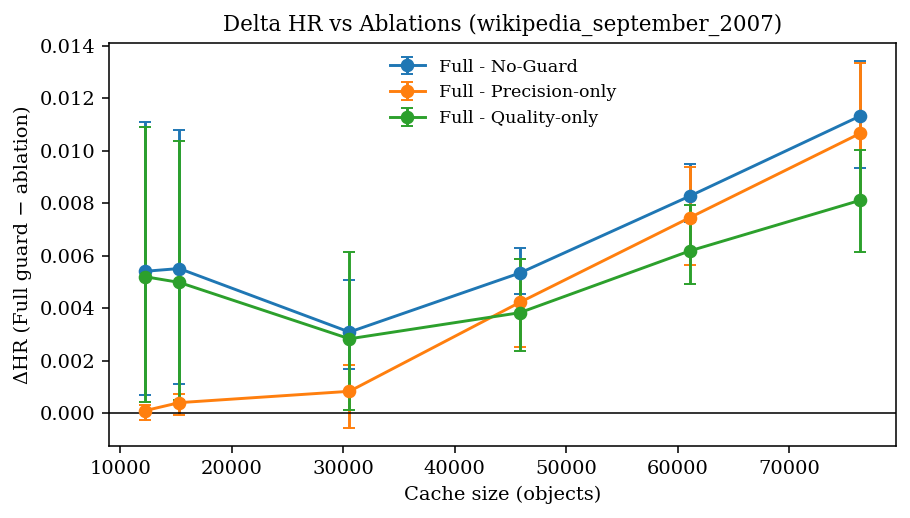

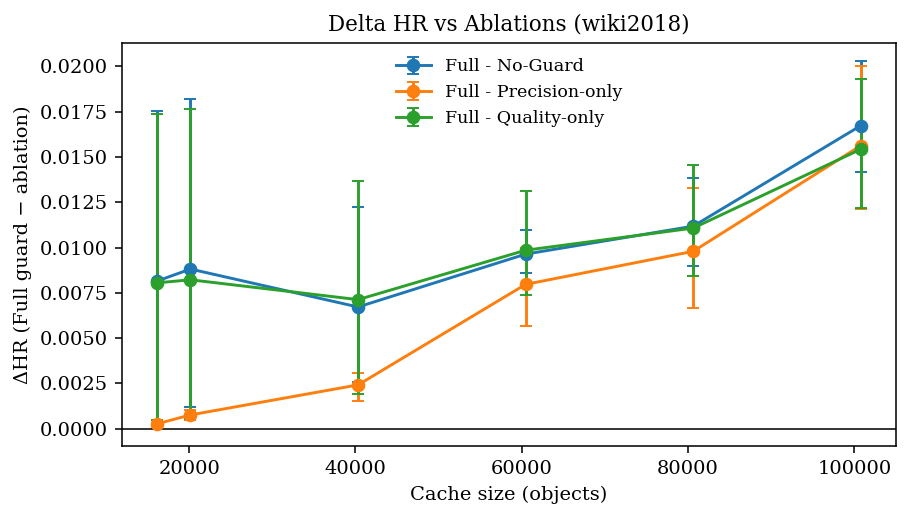

In [11]:
# Delta HR with CI: Full guard vs ablations

delta_rows = []
for dataset, root in DATASETS.items():
    sizes_full = list_sizes(root, VARIANTS['full_guard'])
    for other in ['no_guard', 'precision_only', 'quality_only']:
        sizes_other = list_sizes(root, VARIANTS[other])
        sizes = sorted(set(sizes_full) & set(sizes_other))
        for size in sizes:
            hr_full = load_slot_hr(root, VARIANTS['full_guard'], size)
            hr_other = load_slot_hr(root, VARIANTS[other], size)
            d, lo, hi = block_bootstrap_mean_diff(hr_full, hr_other)
            delta_rows.append({
                'dataset': dataset,
                'cache_size': size,
                'comparison': f"Full - {VARIANT_LABELS[other]}",
                'delta_hr': d,
                'ci_lo': lo,
                'ci_hi': hi,
            })

delta_hr = pd.DataFrame(delta_rows)

for dataset in DATASETS.keys():
    data = delta_hr[delta_hr['dataset'] == dataset]
    fig, ax = plt.subplots(figsize=(6.6, 3.8))
    for comp, g in data.groupby('comparison'):
        g = g.sort_values('cache_size')
        x = g['cache_size'].values
        y = g['delta_hr'].values
        yerr = np.vstack([y - g['ci_lo'].values, g['ci_hi'].values - y])
        ax.errorbar(x, y, yerr=yerr, marker='o', capsize=3, label=comp)

    ax.axhline(0.0, color='black', linewidth=0.8)
    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('ΔHR (Full guard − ablation)')
    ax.set_title(f'Delta HR vs Ablations ({dataset})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'guardrails_delta_hr_{dataset}.png')
    fig.savefig(FIG_DIR / f'guardrails_delta_hr_{dataset}.pdf')
    plt.show()
    plt.close(fig)


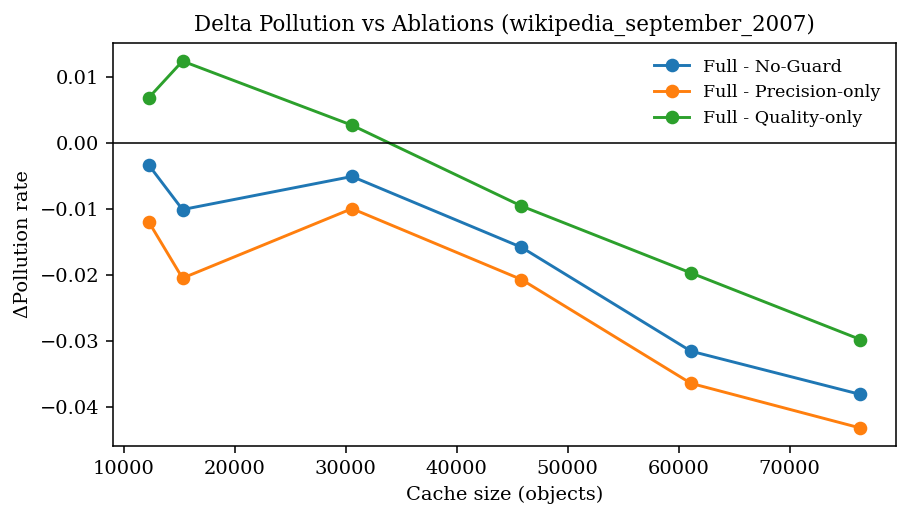

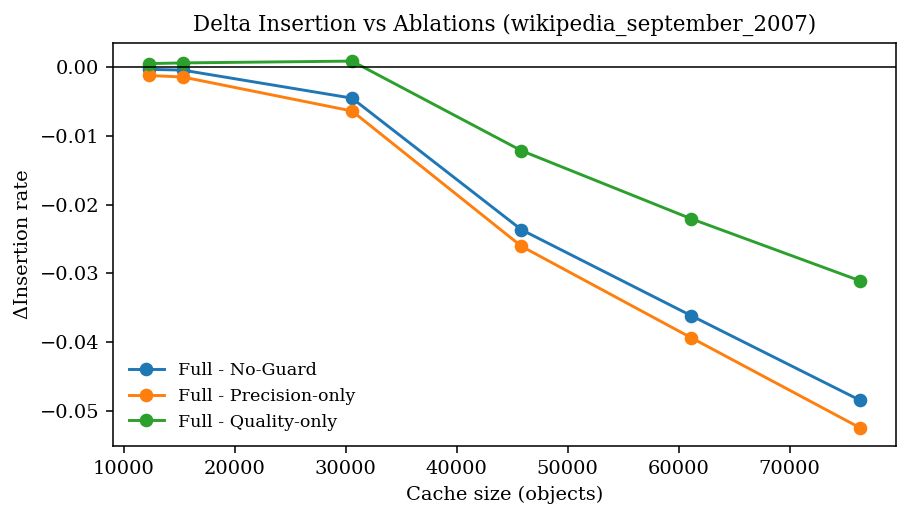

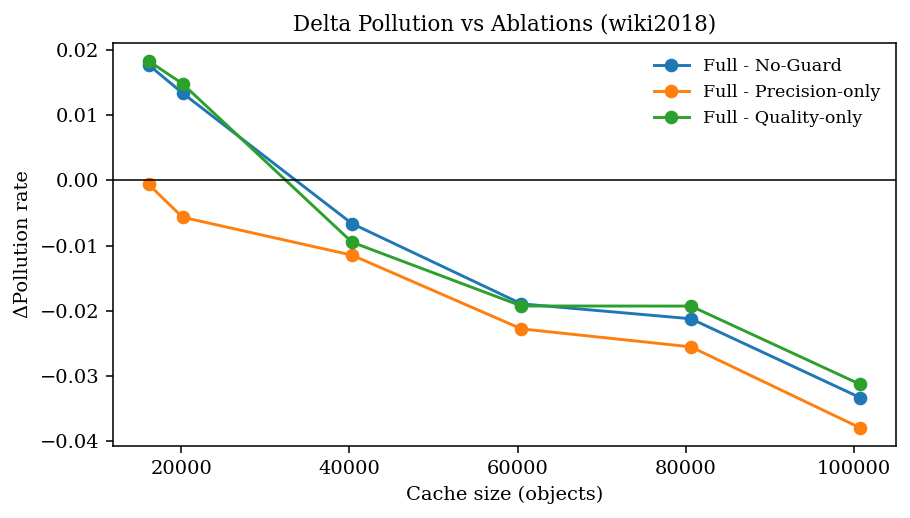

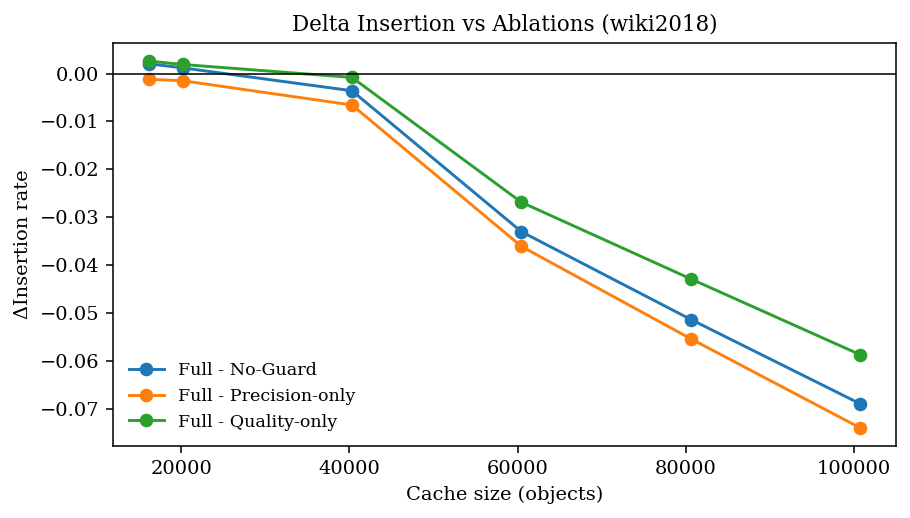

In [12]:
# Delta pollution / insertion (no CI; summary-level)
for dataset in DATASETS.keys():
    df = metrics[metrics['dataset'] == dataset]

    fig, ax = plt.subplots(figsize=(6.6, 3.8))
    for other in ['no_guard', 'precision_only', 'quality_only']:
        full = df[df['variant'] == 'full_guard'][['cache_size', 'pollution_rate_total']].rename(columns={'pollution_rate_total': 'full'})
        oth = df[df['variant'] == other][['cache_size', 'pollution_rate_total']].rename(columns={'pollution_rate_total': 'other'})
        merged = full.merge(oth, on='cache_size', how='inner')
        merged['delta'] = merged['full'] - merged['other']
        merged = merged.sort_values('cache_size')
        ax.plot(merged['cache_size'], merged['delta'], marker='o', label=f"Full - {VARIANT_LABELS[other]}")

    ax.axhline(0.0, color='black', linewidth=0.8)
    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('ΔPollution rate')
    ax.set_title(f'Delta Pollution vs Ablations ({dataset})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'guardrails_delta_pollution_{dataset}.png')
    fig.savefig(FIG_DIR / f'guardrails_delta_pollution_{dataset}.pdf')
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6.6, 3.8))
    for other in ['no_guard', 'precision_only', 'quality_only']:
        full = df[df['variant'] == 'full_guard'][['cache_size', 'admission_rate_requests']].rename(columns={'admission_rate_requests': 'full'})
        oth = df[df['variant'] == other][['cache_size', 'admission_rate_requests']].rename(columns={'admission_rate_requests': 'other'})
        merged = full.merge(oth, on='cache_size', how='inner')
        merged['delta'] = merged['full'] - merged['other']
        merged = merged.sort_values('cache_size')
        ax.plot(merged['cache_size'], merged['delta'], marker='o', label=f"Full - {VARIANT_LABELS[other]}")

    ax.axhline(0.0, color='black', linewidth=0.8)
    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('ΔInsertion rate')
    ax.set_title(f'Delta Insertion vs Ablations ({dataset})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'guardrails_delta_insertion_{dataset}.png')
    fig.savefig(FIG_DIR / f'guardrails_delta_insertion_{dataset}.pdf')
    plt.show()
    plt.close(fig)


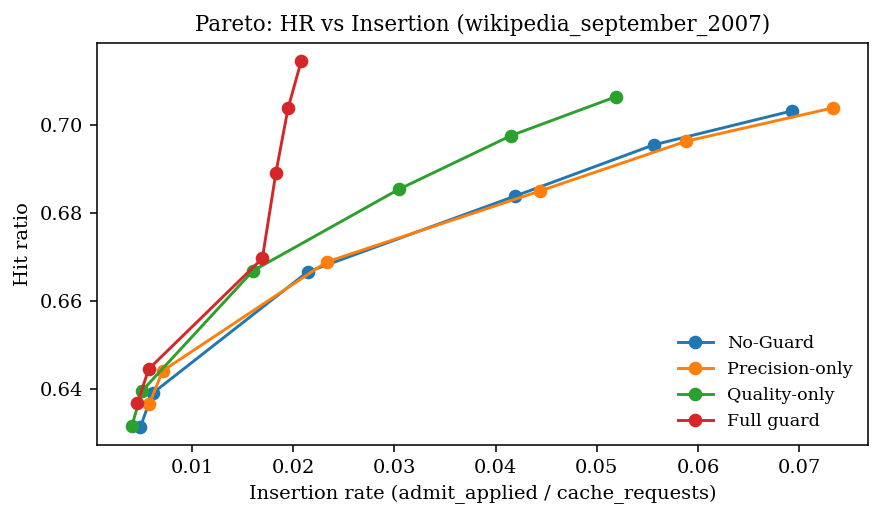

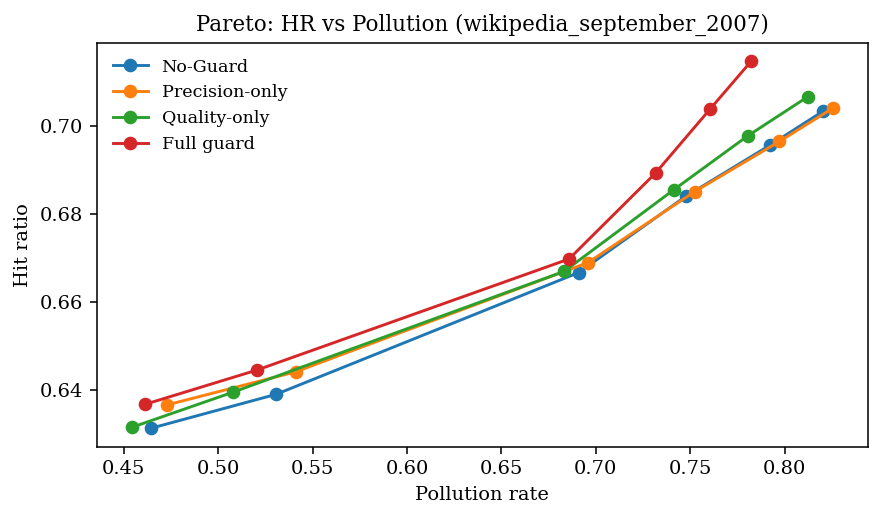

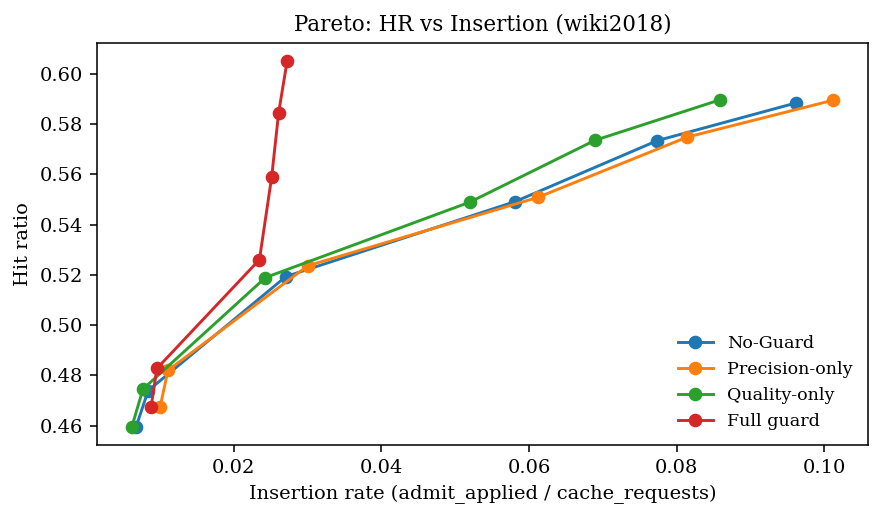

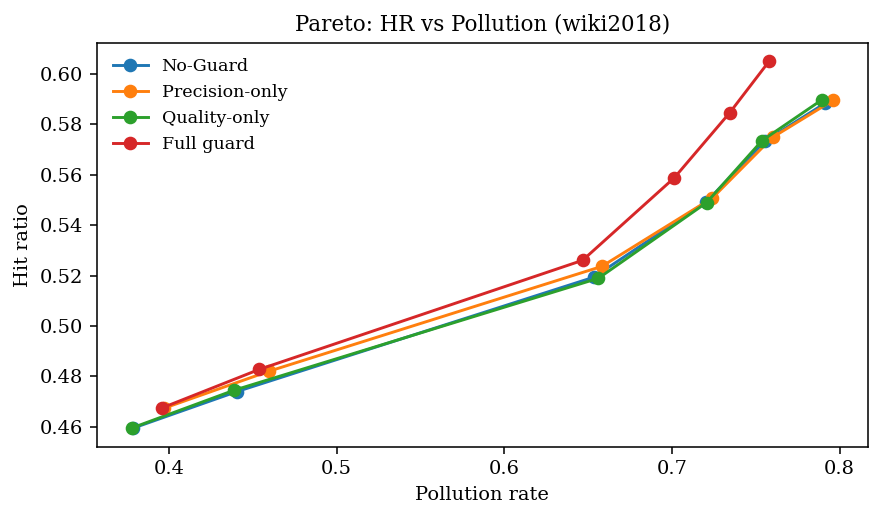

In [13]:
# Pareto curves: HR vs Insertion rate and HR vs Pollution
for dataset in DATASETS.keys():
    df = metrics[metrics['dataset'] == dataset]
    fig, ax = plt.subplots(figsize=(6.4, 3.8))
    for vkey in ['no_guard', 'precision_only', 'quality_only', 'full_guard']:
        g = df[df['variant'] == vkey].sort_values('cache_size')
        ax.plot(g['admission_rate_requests'], g['hit_ratio'], marker='o', label=VARIANT_LABELS[vkey])
    ax.set_xlabel('Insertion rate (admit_applied / cache_requests)')
    ax.set_ylabel('Hit ratio')
    ax.set_title(f'Pareto: HR vs Insertion ({dataset})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'guardrails_pareto_hr_insertion_{dataset}.png')
    fig.savefig(FIG_DIR / f'guardrails_pareto_hr_insertion_{dataset}.pdf')
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6.4, 3.8))
    for vkey in ['no_guard', 'precision_only', 'quality_only', 'full_guard']:
        g = df[df['variant'] == vkey].sort_values('cache_size')
        ax.plot(g['pollution_rate_total'], g['hit_ratio'], marker='o', label=VARIANT_LABELS[vkey])
    ax.set_xlabel('Pollution rate')
    ax.set_ylabel('Hit ratio')
    ax.set_title(f'Pareto: HR vs Pollution ({dataset})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'guardrails_pareto_hr_pollution_{dataset}.png')
    fig.savefig(FIG_DIR / f'guardrails_pareto_hr_pollution_{dataset}.pdf')
    plt.show()
    plt.close(fig)


/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_13060/1986989922.py:108: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[j0:i+1])


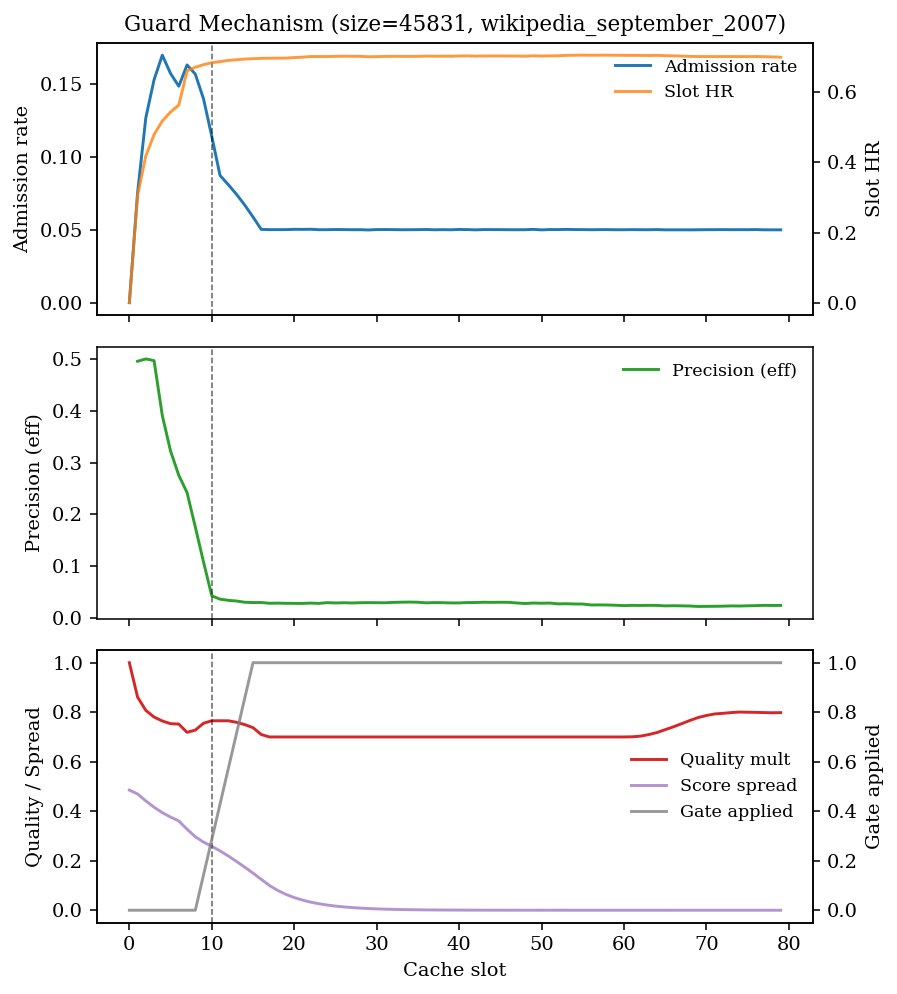

/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_13060/1986989922.py:108: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[j0:i+1])


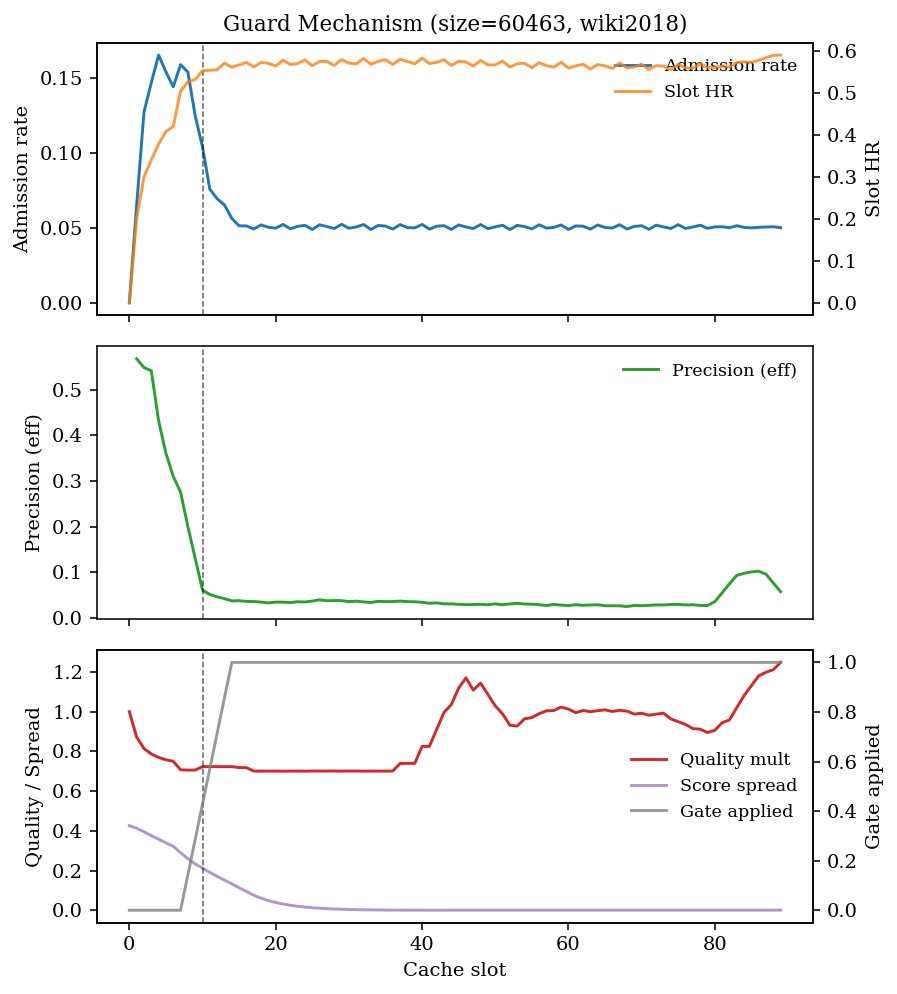

In [14]:
# Mechanism plots with warmup boundary and HR overlay
MECH_VARIANT = 'full_guard'
MECH_WINDOW = 7

for dataset, root in DATASETS.items():
    sizes = list_sizes(root, VARIANTS[MECH_VARIANT])
    if not sizes:
        continue
    size = sizes[len(sizes)//2]
    summary = load_summary(root, VARIANTS[MECH_VARIANT], size)
    warmup_slots = int(summary.get('warmup_slots', 0))

    rows = load_slot_rows(root, VARIANTS[MECH_VARIANT], size)
    miss_candidates = np.array([r.get('miss_candidates') or 0 for r in rows], dtype=float)
    admit_applied = np.array([r.get('admit_applied') or 0 for r in rows], dtype=float)
    admission_rate = np.divide(admit_applied, np.maximum(1.0, miss_candidates))
    slot_hr = np.array([r.get('slot_hit_ratio') if r.get('slot_hit_ratio') is not None else np.nan for r in rows], dtype=float)

    precision_eff = np.array([
        r.get('admission_precision_eff') if r.get('admission_precision_eff') is not None else np.nan
        for r in rows
    ], dtype=float)
    quality_mult = np.array([r.get('quality_mult', np.nan) for r in rows], dtype=float)
    spread = np.array([
        r.get('score_spread_ema') if r.get('score_spread_ema') is not None else r.get('score_spread', np.nan)
        for r in rows
    ], dtype=float)
    gate_applied = np.array([1.0 if r.get('score_gate_applied') else 0.0 for r in rows], dtype=float)

    admission_rate_s = smooth_series(admission_rate, MECH_WINDOW)
    slot_hr_s = smooth_series(slot_hr, MECH_WINDOW)
    precision_eff_s = smooth_series(precision_eff, MECH_WINDOW)
    quality_mult_s = smooth_series(quality_mult, MECH_WINDOW)
    spread_s = smooth_series(spread, MECH_WINDOW)
    gate_applied_s = smooth_series(gate_applied, MECH_WINDOW)

    fig, axes = plt.subplots(3, 1, figsize=(6.6, 7.2), sharex=True)

    # Panel 1: admission rate + HR
    ax = axes[0]
    ax.plot(admission_rate_s, color='tab:blue', label='Admission rate')
    ax2 = ax.twinx()
    ax2.plot(slot_hr_s, color='tab:orange', label='Slot HR', alpha=0.8)
    ax.set_ylabel('Admission rate')
    ax2.set_ylabel('Slot HR')
    ax.set_title(f'Guard Mechanism (size={size}, {dataset})')
    lines = ax.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='best', frameon=False)

    # Panel 2: precision eff
    ax = axes[1]
    ax.plot(precision_eff_s, color='tab:green', label='Precision (eff)')
    ax.set_ylabel('Precision (eff)')
    ax.legend(loc='best', frameon=False)

    # Panel 3: quality/spread + gate
    ax = axes[2]
    ax.plot(quality_mult_s, color='tab:red', label='Quality mult')
    ax.plot(spread_s, color='tab:purple', alpha=0.7, label='Score spread')
    ax2 = ax.twinx()
    ax2.plot(gate_applied_s, color='tab:gray', label='Gate applied', alpha=0.8)
    ax.set_ylabel('Quality / Spread')
    ax2.set_ylabel('Gate applied')
    ax.set_xlabel('Cache slot')
    lines = ax.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='best', frameon=False)

    for ax in axes:
        if warmup_slots > 0:
            ax.axvline(warmup_slots, color='black', linestyle='--', linewidth=0.8, alpha=0.6)

    fig.tight_layout()
    fig.savefig(FIG_DIR / f'guardrails_mech_panel_{dataset}.png')
    fig.savefig(FIG_DIR / f'guardrails_mech_panel_{dataset}.pdf')
    plt.show()
    plt.close(fig)
